In [23]:
netlist = """\
DC Circuit 1
Vs  A  0  DC $VS
R1  A  B  5
R2  B  0  10
R3  B  C  5
R4  C  0  5
Is  0  C  DC 2
.SAVE v(a) v(b) v(c)
.OP
.END
"""

with open('dc_circuit_1_orig.in', 'w') as f:
    f.write(netlist)

print('dc_circuit_1_orig.in written')

dc_circuit_1_orig.in written


In [24]:
import sys, os
sys.path.insert(0, os.path.abspath('../../'))  

In [25]:
import numpy as np
import ngspice_calc as calc
import matplotlib.pyplot as plt

#User parameters 
Vs = 4.0   

print(f'Vs = {Vs} V')

Vs = 4.0 V


In [26]:
l = [
    ('$VS', f'{Vs}'),
]

calc.replace_strings_1('dc_circuit_1_orig.in', 'dc_circuit_1.in', l)
calc.run_ngspice('dc_circuit_1.in')


No compatibility mode selected!


Circuit: dc circuit 1

binary raw file "dc_circuit_1.raw"
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

No. of Data Columns : 3  

No. of Data Rows : 1

Total analysis time (seconds) = 0

Total elapsed time (seconds) = 0.002 

Total DRAM available = 14741.164 MB.
DRAM currently available = 3189.777 MB.
Maximum ngspice program size =   19.910 MB.
Current ngspice program size =   11.918 MB.

Shared ngspice pages =   10.059 MB.
Text (code) pages =    5.316 MB.
Stack = 0 bytes.
Library pages =    1.965 MB.




'dc_circuit_1.raw'

In [27]:
s = calc.slv('dc_circuit_1.in')

for i in range(s.num_plots()):
    print(f"  plot {i}: {s.plotname(i)} | type: {s.analysis_type(i)} | vars: {s.variables(i)}")

  plot 0: Operating Point | type: op | vars: ['v(a)', 'v(b)', 'v(c)']


In [28]:
VA = s.get_array('v(a)')[0]
VB = s.get_array('v(b)')[0]
VC = s.get_array('v(c)')[0]

print(f'VA = {VA:7.4f} V')
print(f'VB = {VB:7.4f} V')
print(f'VC = {VC:7.4f} V')

VA =  4.0000 V
VB =  4.5000 V
VC =  7.2500 V


In [29]:
A_mat = np.array([
    [-(1/5 + 1/10 + 1/5),  1/5],
    [ 1/5,                -(1/5 + 1/5)],
])
b_vec = np.array([-Vs/5, -2.0])

VB_calc, VC_calc = np.linalg.solve(A_mat, b_vec)
VA_calc = Vs

print(' Hand calculation')
print(f'VA = {VA_calc:7.4f} V')
print(f'VB = {VB_calc:7.4f} V')
print(f'VC = {VC_calc:7.4f} V')
print()
print(' NGSPICE ')
print(f'VA = {VA:7.4f} V')
print(f'VB = {VB:7.4f} V')
print(f'VC = {VC:7.4f} V')
print()
tol = 1e-4


 Hand calculation
VA =  4.0000 V
VB =  4.5000 V
VC =  7.2500 V

 NGSPICE 
VA =  4.0000 V
VB =  4.5000 V
VC =  7.2500 V



In [30]:
sweep_netlist = """\
DC Circuit 1 — Sweep
Vs  A  0  DC 1
R1  A  B  5
R2  B  0  10
R3  B  C  5
R4  C  0  5
Is  C  0  DC 2
.SAVE v(a) v(b) v(c)
.DC Vs 1.0 5.0 0.2
.END
"""

with open('dc_circuit_1_sweep.in', 'w') as f:
    f.write(sweep_netlist)

calc.run_ngspice('dc_circuit_1_sweep.in')

s_sw = calc.slv('dc_circuit_1_sweep.in')
Vs_arr = s_sw.get_array('v-sweep')
VA_arr = s_sw.get_array('v(a)')
VB_arr = s_sw.get_array('v(b)')
VC_arr = s_sw.get_array('v(c)')

print(f'{"Vs":>8} {"VA":>8} {"VB":>8} {"VC":>8}')
for vs, va, vb, vc in zip(Vs_arr, VA_arr, VB_arr, VC_arr):
    print(f'{vs:8.2f} {va:8.4f} {vb:8.4f} {vc:8.4f}')


No compatibility mode selected!


Circuit: dc circuit 1 — sweep

binary raw file "dc_circuit_1_sweep.raw"
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

No. of Data Columns : 4  

No. of Data Rows : 21

Total analysis time (seconds) = 0.001

Total elapsed time (seconds) = 0.003 

Total DRAM available = 14741.164 MB.
DRAM currently available = 3230.969 MB.
Maximum ngspice program size =   19.906 MB.
Current ngspice program size =   12.051 MB.

Shared ngspice pages =   10.195 MB.
Text (code) pages =    5.316 MB.
Stack = 0 bytes.
Library pages =    1.961 MB.


      Vs       VA       VB       VC
    1.00   1.0000  -2.0000  -6.0000
    1.20   1.2000  -1.9000  -5.9500
    1.40   1.4000  -1.8000  -5.9000
    1.60   1.6000  -1.7000  -5.8500
    1.80   1.8000  -1.6000  -5.8000
    2.00   2.0000  -1.5000  -5.7500
    2.20   2.2000  -1.4000  -5.7000
    2.40   2.4000  -1.3000  -5.6500
    2.60   2.6000  -1.2000  -5.6000
    2.80   2.8000  -1.1000  -5.5500
    3.00   3.0000  -1.0000  -

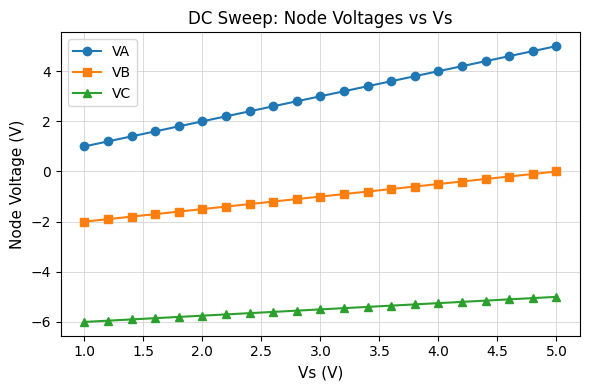

In [31]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(Vs_arr, VA_arr, marker='o', label='VA')
ax.plot(Vs_arr, VB_arr, marker='s', label='VB')
ax.plot(Vs_arr, VC_arr, marker='^', label='VC')
ax.set_xlabel('Vs (V)', fontsize=11)
ax.set_ylabel('Node Voltage (V)', fontsize=11)
ax.set_title('DC Sweep: Node Voltages vs Vs', fontsize=12)
ax.legend()
ax.grid(color='#CCCCCC', linestyle='solid', linewidth=0.5)
plt.tight_layout()
plt.show()